In [1]:
%load_ext autoreload
%autoreload 2

In [55]:
import pandas as pd

pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 500)

# 1. Liga pokemon

In [51]:
import pandas as pd
from crawl_0 import crawl_pokemon_variations
rows = crawl_pokemon_variations()

cloudscraper_get: url='https://www.ligapokemon.com.br/?view=cards/variacao&show=alta&formato=&order=2'
parse_cards_json...


In [ ]:
colecoes = [
    # "https://www.ligapokemon.com.br/?view=cards/search&card=edid=769%20ed=POR",
    "https://www.ligapokemon.com.br/?view=cards/search&card=edid=754%20ed=ASC",
    "https://www.ligapokemon.com.br/?view=cards/search&card=edid=738%20ed=PFL",
    "https://www.ligapokemon.com.br/?view=cards/search&card=edid=730%20ed=MEG",
    "https://www.ligapokemon.com.br/?view=cards/search&card=edid=722%20ed=WHT",
    "https://www.ligapokemon.com.br/?view=cards/search&card=edid=721%20ed=BLK",
    "https://www.ligapokemon.com.br/?view=cards/search&card=edid=706%20ed=DRI",
    "https://www.ligapokemon.com.br/?view=cards/search&card=edid=654%20ed=JTG",
    "https://www.ligapokemon.com.br/?view=cards/search&card=edid=649%20ed=PRE",  # Evoluções Prismáticas
    "https://www.ligapokemon.com.br/?view=cards/search&card=edid=639%20ed=SSP",
    "https://www.ligapokemon.com.br/?view=cards/search&card=edid=633%20ed=SV8",
    "https://www.ligapokemon.com.br/?view=cards/search&card=edid=612%20ed=SCR",
]

In [59]:
import pandas as pd
from crawl_0 import crawl_pokemon_variations, crawl_pokemon_set

dfs = []
for url in colecoes:
    rows = crawl_pokemon_set(url)
    df_rows = pd.DataFrame(rows)
    df_rows["url"] = url
    dfs.append(df_rows)

selenium_get: url='https://www.ligapokemon.com.br/?view=cards/search&card=edid=769%20ed=POR'
Attempt 1/3: Loading page...
Success! Page loaded.
parse_cards_json...
Could not find cardsjson variable in the HTML!
selenium_get: url='https://www.ligapokemon.com.br/?view=cards/search&card=edid=754%20ed=ASC'
Attempt 1/3: Loading page...
Success! Page loaded.
parse_cards_json...
selenium_get: url='https://www.ligapokemon.com.br/?view=cards/search&card=edid=738%20ed=PFL'
Attempt 1/3: Loading page...
Success! Page loaded.
parse_cards_json...
selenium_get: url='https://www.ligapokemon.com.br/?view=cards/search&card=edid=730%20ed=MEG'
Attempt 1/3: Loading page...
Success! Page loaded.
parse_cards_json...
selenium_get: url='https://www.ligapokemon.com.br/?view=cards/search&card=edid=722%20ed=WHT'
Attempt 1/3: Loading page...
Success! Page loaded.
parse_cards_json...
selenium_get: url='https://www.ligapokemon.com.br/?view=cards/search&card=edid=721%20ed=BLK'
Attempt 1/3: Loading page...
Success! Pa

In [112]:
df_full = pd.concat(dfs, ignore_index=True)

In [117]:
df_full.to_csv("df_full.csv", encoding="utf-8-sig", index=False)

In [118]:
import html

for c in df_full.columns:
    if str(df_full[c].dtype) in ["object", "str"]:
        df_full[c] = df_full[c].apply(lambda x: html.unescape(x) if isinstance(x, str) else x)

In [119]:
renames = {
    "sSigla": "colecao",
    "id": "id",
    'sN': "num",
    "nEN": "nome_en",
    "nPT": "nome_pt",
    "p1a": "preco_min",
    "p1b": "preco_mean",
    "p1c": "preco_max",
    "iR": "num_raridade",
    "sP": "path_img",
    "dt": "date",

    "ed_sNome": "colecao_nome_en",
    "iRaridade": "num_raridade",
    "raridade": "raridade",
    "varianciaSemFormat": "preco_variacao",
    "sNomeIngles": "nome_en2",
    "sNomePortugues": "nome_pt2",
}

In [120]:
df_full = df_full.rename(columns=renames)
cols = df_full.columns.to_list()
df_full = df_full[[c for c in cols if c in renames.values()]]
df_full

,colecao,id,nome_en,nome_pt,num,preco_min,preco_mean,preco_max,date,num_raridade,path_img
0,ASC,1337.0,Erika's Oddish (#001/217),Oddish da Érica,001,0.14,1.19,4.75,2026-01-30 15:44:24,1.0,//arquivos/in/pokemon_bkp/cd/754/697cf0b8bf6da...
1,ASC,1336.0,Erika's Gloom (#002/217),Gloom da Érica,002,0.14,1.74,3.99,2026-01-30 15:44:25,2.0,//arquivos/in/pokemon_bkp/cd/754/697cf0ba6d14f...
2,ASC,8164.0,Erika's Vileplume ex (#003/217),Vileplume ex da Érica,003,5.00,13.66,22.90,2026-01-30 15:44:27,20.0,//arquivos/in/pokemon_bkp/cd/754/697cf0bc01ad8...
3,ASC,1356.0,Erika's Bellsprout (#004/217),Bellsprout da Érica,004,0.19,1.28,5.00,2026-01-30 15:44:28,1.0,//arquivos/in/pokemon_bkp/cd/754/697cf0bd99b2d...
4,ASC,1338.0,Erika's Weepinbell (#005/217),Weepinbell da Érica,005,0.15,1.68,4.25,2026-01-30 15:44:30,2.0,//arquivos/in/pokemon_bkp/cd/754/697cf0bf85d43...
...,...,...,...,...,...,...,...,...,...,...,...
2132,SCR,7093.0,Briar (#171/142),Urzy,171,69.90,102.33,171.99,2024-09-11 16:08:56,18.0,//arquivos/in/pokemon_bkp/cd/612/66e30c091b3d1...
2133,SCR,7091.0,Lacey (#172/142),Tarsila,172,66.30,109.74,199.99,2024-09-10 17:45:23,18.0,//arquivos/in/pokemon_bkp/cd/612/66e30c0ae1607...
2134,SCR,7081.0,Terapagos ex (#173/142),Terapagos ex,173,44.90,82.84,300.00,2024-09-11 16:08:56,15.0,//arquivos/in/pokemon_bkp/cd/612/66e30c0cdc319...
2135,SCR,7095.0,Area Zero Underdepths (#174/142),Abismo da Área Zero,174,39.20,71.00,167.76,2024-09-11 16:08:56,15.0,//arquivos/in/pokemon_bkp/cd/612/66e30c0ed5cb0...


In [121]:
precos = df_full.filter(regex="preco").columns
df_full[precos] = df_full[precos].astype("float64")

In [122]:
# Remove hours
df_full["date"] = pd.to_datetime(df_full["date"]).dt.date

In [123]:
df_group = df_full.groupby("colecao").agg(
    num_cards = ("id", "count"),
    date = ("date", "min"),
    preco_min = ("preco_min", "sum"),
    preco_mean = ("preco_mean", "sum"),
    preco_max = ("preco_max", "sum"),
)
df_group = df_group.sort_values("date", ascending=False).reset_index()
df_group

,colecao,num_cards,date,preco_min,preco_mean,preco_max
0,ASC,295,2026-01-30,14984.89,21903.23,44493.07
1,PFL,130,2025-11-24,3480.45,5671.08,15844.91
2,MEG,188,2025-10-01,4831.47,8874.00,22699.12
3,BLK,172,2025-07-15,6629.50,11458.33,22757.71
4,WHT,173,2025-07-15,6938.32,10109.42,22043.00
5,DRI,244,2025-05-01,5713.59,8427.04,24900.93
6,JTG,190,2025-03-11,1611.34,3377.29,8580.93
7,PRE,180,2025-01-07,14270.98,22797.86,59406.85
8,SSP,252,2024-10-15,4299.52,6553.55,16811.16
9,SV8,138,2024-10-02,4807.15,6049.48,7768.66


In [124]:
for col in precos:
    df_group[col+"_mean"] = df_group[col] / df_group["num_cards"]
df_group.round(1)

,colecao,num_cards,date,preco_min,preco_mean,preco_max,preco_min_mean,preco_mean_mean,preco_max_mean
0,ASC,295,2026-01-30,14984.9,21903.2,44493.1,50.8,74.2,150.8
1,PFL,130,2025-11-24,3480.4,5671.1,15844.9,26.8,43.6,121.9
2,MEG,188,2025-10-01,4831.5,8874.0,22699.1,25.7,47.2,120.7
3,BLK,172,2025-07-15,6629.5,11458.3,22757.7,38.5,66.6,132.3
4,WHT,173,2025-07-15,6938.3,10109.4,22043.0,40.1,58.4,127.4
5,DRI,244,2025-05-01,5713.6,8427.0,24900.9,23.4,34.5,102.1
6,JTG,190,2025-03-11,1611.3,3377.3,8580.9,8.5,17.8,45.2
7,PRE,180,2025-01-07,14271.0,22797.9,59406.8,79.3,126.7,330.0
8,SSP,252,2024-10-15,4299.5,6553.6,16811.2,17.1,26.0,66.7
9,SV8,138,2024-10-02,4807.2,6049.5,7768.7,34.8,43.8,56.3


<Axes: xlabel='colecao'>

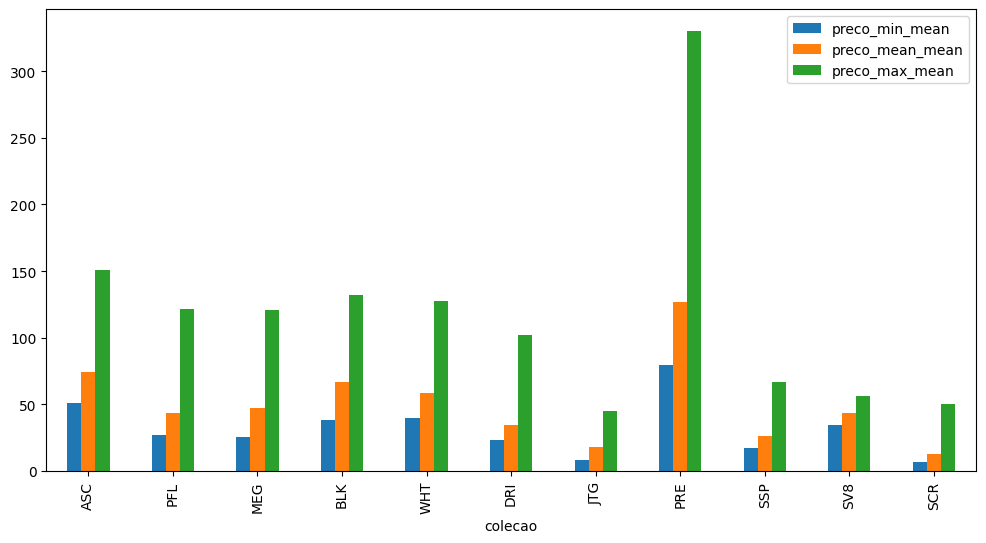

In [125]:
df_group.plot("colecao",["preco_min_mean", "preco_mean_mean", "preco_max_mean"], kind="bar", figsize=(12, 6))

# 3. api tcgdexsdk

In [1]:
from tcgdexsdk import TCGdex, Language, Query

tcgdex = TCGdex("en") # "pt-br")

# Pegando todos os sets, exceto os do tcg pocket
sets = await tcgdex.set.list(Query().notEqual("serie.id", 'tcgp').sort("releaseDate", "desc"))
len(sets)

186

In [2]:
sets = sets[:1]
sets

[SetResume(sdk=<tcgdexsdk.tcgdex.TCGdex object at 0x00000273DD467F50>, id='me02.5', name='Ascended Heroes', logo='https://assets.tcgdex.net/en/me/me02.5/logo', symbol='https://assets.tcgdex.net/univ/me/me02.5/symbol', cardCount=SetCardCountResume(total=295, official=217))]

In [3]:
def sdk_obj_to_dict(obj, prefix=""):
    obj_dict = obj.__dict__
    obj_dict = {prefix+k:v for k,v in obj_dict.items() if isinstance(v, (int, float, str, bool, type(None)))}
    return obj_dict

In [42]:
from tqdm import tqdm
rows = []

extension = "png"
quality = "low"

for i, set_brief in enumerate(sets):
    print(f"Processing set {i+1}/{len(sets)}: {set_brief.name}")
    full_set = await sets[0].get_full_set()
    full_set_dict = sdk_obj_to_dict(full_set, prefix="set_")
    for card in tqdm(full_set.cards):
        image_url = card.get_image_url(quality=quality, extension=extension)
        image_data = card.get_image(quality=quality, format=extension)
        image_path = f"images/{full_set.releaseDate}_{full_set.id}_{card.id}_{quality}.{extension}"
        with open(image_path, "wb") as f:
            f.write(image_data.read())
        card_full = await card.get_full_card()
        variants_dict = sdk_obj_to_dict(card_full.variants, "variants_")
        card_dict = sdk_obj_to_dict(card_full)
        rows.append({
            **full_set_dict,
            **card_dict,
            "image_url": image_url,
            "image_path": image_path,
            **variants_dict
        })


Processing set 1/1: Ascended Heroes


  0%|          | 0/295 [00:00<?, ?it/s]

100%|██████████| 295/295 [10:37<00:00,  2.16s/it]


In [30]:
dir(image_data)

['__abstractmethods__',
 '__class__',
 '__del__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__enter__',
 '__eq__',
 '__exit__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__next__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '_abc_impl',
 '_checkClosed',
 '_checkReadable',
 '_checkSeekable',
 '_checkWritable',
 '_check_close',
 '_close_conn',
 '_get_chunk_left',
 '_method',
 '_peek_chunked',
 '_read1_chunked',
 '_read_and_discard_trailer',
 '_read_chunked',
 '_read_next_chunk_size',
 '_read_status',
 '_readinto_chunked',
 '_safe_read',
 '_safe_readinto',
 'begin',
 'chunk_left',
 'chunked',
 'close',
 'closed',
 'code',
 'debuglevel',
 'detach',
 'fileno',
 'flush',
 'fp',
 'getcode',
 'getheader',
 'getheaders',
 'geturl',
 'headers',
 'info',
 'isatty'

In [36]:
png_bytes = image_data.read()

# Display image
from PIL import Image
from io import BytesIO

image = Image.open(BytesIO(png_bytes))
image.show()

UnidentifiedImageError: cannot identify image file <_io.BytesIO object at 0x00000273DFA94590>

In [ ]:
import asyncio
from tqdm.notebook import tqdm 

async def get_set_data(set_brief, semaphore):
    async with semaphore:
        # Micro-pausa para o Jupyter conseguir renderizar a UI
        # await asyncio.sleep(0) 
        full_set = await set_brief.get_full_set()
        return full_set

async def process_card(card, full_set_dict, semaphore):
    async with semaphore:
        # await asyncio.sleep(0) # Força a atualização da interface
        
        image_url = card.get_image_url(quality="low", extension="png")
        
        # Se essa linha demorar e a barra travar, o SDK é síncrono por baixo dos panos
        card_full = await card.get_full_card() 
        
        variants_dict = sdk_obj_to_dict(card_full.variants, "variants_")
        card_dict = sdk_obj_to_dict(card_full)
        
        return {
            **full_set_dict,
            **card_dict,
            "image_url": image_url,
            **variants_dict
        }

async def main_processor(sets):
    semaphore = asyncio.Semaphore(30) 
    
    # --- ETAPA 1: Processar Sets ---
    # CRIAR TAREFAS (Tasks) explicitamente faz com que elas comecem a rodar no background AGORA
    set_tasks = [asyncio.create_task(get_set_data(set_brief, semaphore)) for set_brief in sets]
    
    full_sets = []
    for task in tqdm(asyncio.as_completed(set_tasks), total=len(set_tasks), desc="1/2 Baixando Sets"):
        result = await task
        full_sets.append(result)
    
    # --- ETAPA 2: Preparar as tarefas das cartas ---
    card_tasks = []
    for full_set in full_sets:
        full_set_dict = sdk_obj_to_dict(full_set, prefix="set_")
        for card in full_set.cards:
            # Novamente, encapsular em create_task!
            task = asyncio.create_task(process_card(card, full_set_dict, semaphore))
            card_tasks.append(task)
            
    # --- ETAPA 3: Processar Cartas ---
    rows = []
    for task in tqdm(asyncio.as_completed(card_tasks), total=len(card_tasks), desc="2/2 Baixando Cartas"):
        result = await task 
        rows.append(result)
    
    return rows

In [ ]:
# Como rodar:
rows = await main_processor(sets)

1/2 Baixando Sets:   0%|          | 0/1 [00:00<?, ?it/s]

2/2 Baixando Cartas:   0%|          | 0/295 [00:00<?, ?it/s]

In [6]:
rows

[{'set_id': 'me02.5',
  'set_name': 'Ascended Heroes',
  'set_logo': 'https://assets.tcgdex.net/en/me/me02.5/logo',
  'set_symbol': 'https://assets.tcgdex.net/univ/me/me02.5/symbol',
  'set_tcgOnline': None,
  'set_releaseDate': '2026-01-30',
  'set_boosters': None,
  'illustrator': 'Yoriyuki Ikegami',
  'rarity': 'Common',
  'category': 'Pokemon',
  'dexId': None,
  'hp': 60,
  'evolveFrom': None,
  'description': None,
  'level': None,
  'stage': 'Basic',
  'suffix': None,
  'item': None,
  'abilities': None,
  'weaknesses': None,
  'resistances': None,
  'retreat': 1,
  'effect': None,
  'trainerType': None,
  'energyType': None,
  'regulationMark': 'J',
  'id': 'me02.5-001',
  'localId': '001',
  'name': "Erika's Oddish",
  'image': 'https://assets.tcgdex.net/en/me/me02.5/001',
  'boosters': None,
  'image_url': 'https://assets.tcgdex.net/en/me/me02.5/001/low.png',
  'variants_normal': True,
  'variants_reverse': True,
  'variants_holo': True,
  'variants_firstEdition': False,
  'v

In [43]:
import pandas as pd

pd.DataFrame(rows).to_csv("cards_data.csv", index=False)

In [ ]:
for i, set_brief in enumerate(sets):
    print(f"Processing set {i+1}/{len(sets)}: {set_brief.name}")
    full_set = await sets[0].get_full_set()
    full_set_dict = sdk_obj_to_dict(full_set, prefix="set_")
    for i, card in enumerate(full_set.cards):
        print(f"    Processing card {i+1}/{len(full_set.cards)}: {card.name}")
        image_url = card.get_image_url(quality="low", extension="png")
        card_full = await card.get_full_card()
        variants_dict = sdk_obj_to_dict(card_full.variants, "variants_")
        card_dict = sdk_obj_to_dict(card_full)
        rows.append({
            **full_set_dict,
            **card_dict,
            "image_url": image_url,
            **variants_dict
        })

In [151]:
rows[0]

{'set_id': 'me02.5',
 'set_name': 'Ascended Heroes',
 'set_logo': 'https://assets.tcgdex.net/en/me/me02.5/logo',
 'set_symbol': 'https://assets.tcgdex.net/univ/me/me02.5/symbol',
 'set_tcgOnline': None,
 'set_releaseDate': '2026-01-30',
 'set_boosters': None,
 'illustrator': 'Yoriyuki Ikegami',
 'rarity': 'Common',
 'category': 'Pokemon',
 'dexId': None,
 'hp': 60,
 'evolveFrom': None,
 'description': None,
 'level': None,
 'stage': 'Basic',
 'suffix': None,
 'item': None,
 'abilities': None,
 'weaknesses': None,
 'resistances': None,
 'retreat': 1,
 'effect': None,
 'trainerType': None,
 'energyType': None,
 'regulationMark': 'J',
 'id': 'me02.5-001',
 'localId': '001',
 'name': "Erika's Oddish",
 'image': 'https://assets.tcgdex.net/en/me/me02.5/001',
 'boosters': None,
 'image_url': 'https://assets.tcgdex.net/en/me/me02.5/001/low.png',
 'variants_normal': True,
 'variants_reverse': True,
 'variants_holo': True,
 'variants_firstEdition': False,
 'variants_wPromo': False}

In [141]:
card_full.__dict__

{'illustrator': 'Yoriyuki Ikegami',
 'rarity': 'Common',
 'category': 'Pokemon',
 'variants': CardVariants(normal=True, reverse=True, holo=True, firstEdition=False, wPromo=False),
 'set': SetResume(sdk=<tcgdexsdk.tcgdex.TCGdex object at 0x000002389A0EFD10>, id='me02.5', name='Ascended Heroes', logo='https://assets.tcgdex.net/en/me/me02.5/logo', symbol='https://assets.tcgdex.net/univ/me/me02.5/symbol', cardCount=SetCardCountResume(total=295, official=217)),
 'dexId': None,
 'hp': 60,
 'types': ['Grass'],
 'evolveFrom': None,
 'description': None,
 'level': None,
 'stage': 'Basic',
 'suffix': None,
 'item': None,
 'abilities': None,
 'attacks': [CardAttack(name='Reckless Charge', cost=['Grass'], effect='This Pokémon also does 10 damage to itself.', damage=30)],
 'weaknesses': None,
 'resistances': None,
 'retreat': 1,
 'effect': None,
 'trainerType': None,
 'energyType': None,
 'regulationMark': 'J',
 'legal': Legal(standard=False, expanded=False),
 'id': 'me02.5-001',
 'localId': '001',

In [139]:
rows

[{'set_id': 'me02.5',
  'set_name': 'Ascended Heroes',
  'set_logo': 'https://assets.tcgdex.net/en/me/me02.5/logo',
  'set_symbol': 'https://assets.tcgdex.net/univ/me/me02.5/symbol',
  'set_releaseDate': '2026-01-30',
  'illustrator': 'Yoriyuki Ikegami',
  'rarity': 'Common',
  'category': 'Pokemon',
  'hp': 60,
  'stage': 'Basic',
  'retreat': 1,
  'regulationMark': 'J',
  'id': 'me02.5-001',
  'localId': '001',
  'name': "Erika's Oddish",
  'image': 'https://assets.tcgdex.net/en/me/me02.5/001',
  'image_url': 'https://assets.tcgdex.net/en/me/me02.5/001/low.png'}]

In [80]:
card_full = await card.get_full_card()

In [84]:
card_full.__dict__

{'illustrator': 'Ken Sugimori',
 'rarity': 'Rare',
 'category': 'Pokemon',
 'variants': CardVariants(normal=False, reverse=False, holo=True, firstEdition=True, wPromo=False),
 'set': SetResume(sdk=<tcgdexsdk.tcgdex.TCGdex object at 0x000002389A2FDDC0>, id='base1', name='Base Set', logo='https://assets.tcgdex.net/en/base/base1/logo', symbol=None, cardCount=SetCardCountResume(total=102, official=102)),
 'dexId': [65],
 'hp': 80,
 'types': ['Psychic'],
 'evolveFrom': 'Kadabra',
 'description': None,
 'level': None,
 'stage': 'Stage2',
 'suffix': None,
 'item': None,
 'abilities': [CardAbility(type='Pokemon Power', name='Damage Swap', effect="As often as you like during your turn (before your attack), you may move 1 damage counter from 1 of your Pokémon to another as long as you don't Knock Out that Pokémon. This power can't be used if Alakazam is Asleep, Confused, or Paralyzed.")],
 'attacks': [CardAttack(name='Confuse Ray', cost=['Psychic', 'Psychic', 'Psychic'], effect='Flip a coin. If 

In [ ]:
# Async usage
card = await tcgdex.card.get("swsh3-136")
card

Card(sdk=<tcgdexsdk.tcgdex.TCGdex object at 0x0000023899F358B0>, illustrator='tetsuya koizumi', rarity='Uncommon', category='Pokemon', variants=CardVariants(normal=True, reverse=True, holo=False, firstEdition=False, wPromo=False), set=SetResume(sdk=<tcgdexsdk.tcgdex.TCGdex object at 0x0000023899F358B0>, id='swsh3', name='Darkness Ablaze', logo='https://assets.tcgdex.net/en/swsh/swsh3/logo', symbol='https://assets.tcgdex.net/univ/swsh/swsh3/symbol', cardCount=SetCardCountResume(total=201, official=189)), dexId=[162], hp=110, types=['Colorless'], evolveFrom='Sentret', description='It makes a nest to suit its long and skinny body. The nest is impossible for other Pokémon to enter.', level=None, stage='Stage1', suffix=None, item=None, abilities=None, attacks=[CardAttack(name="Feelin' Fine", cost=['Colorless'], effect='Draw 3 cards.', damage=None), CardAttack(name='Tail Smash', cost=['Colorless'], effect='Flip a coin. If tails, this attack does nothing.', damage=90)], weaknesses=[CardWeakRe

In [40]:
# Get image URL with quality and format
image_url = card.get_image_url(quality="low", extension="png")
image_url

'https://assets.tcgdex.net/en/swsh/swsh3/136/low.png'

In [44]:
image_data = card.get_image(quality="low", format="")
image_data